In [1]:
# ============================================================
# End-to-end LiPar (STParNet) training in Jupyter (FIXED)
# - Fixes CUDA "device-side assert" by using NUM_CLASSES=11 (labels 0..10)
# - Adds missing ConAttKia_Spoof to concat
# - Adds strong sanity checks before training
# ============================================================

import os
import re
import glob
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split

In [2]:
# -----------------------------
# 0) Repro / Debug helpers
# -----------------------------
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

# If you are debugging only, uncomment:
# os.environ["CUDA_LAUNCH_BLOCKING"] = "1"

device = "cuda" if torch.cuda.is_available() else "cpu"
print("device:", device)

# -----------------------------
# 1) Labels and config
# -----------------------------
NUM_CLASSES = 7                      # <-- CRITICAL FIX (0..10)
LABEL_TO_INT = {str(i): i for i in range(NUM_CLASSES)}

# Kia CAN IDs used in your pipeline
kia_id = None #['0018', '0220', '0316', '043F', '0440', '0510']
BYTE_COLS = ["One","Two","Three","Four","Five","Six","Seven","Eight"]

device: cuda


In [3]:
# ------------------------------------------------------------
# 2) Load CSV folders with labels + file_id
# ------------------------------------------------------------
def load_csv_folder_with_label(path: str, lbl: str, group: str) -> pd.DataFrame:
    """
    Load each CSV in 'path' and stamp:
      - Label = lbl ('0'..'10')
      - group (AggKia / ConAttKia / SitAttKia)
      - file_id unique per CSV file (prevents window crossing)
    """
    csv_files = sorted(glob.glob(os.path.join(path, "*.csv")))
    if not csv_files:
        raise FileNotFoundError(f"No CSV files found in: {path}")

    dfs = []
    for f in csv_files:
        df = pd.read_csv(f)
        df["Label"] = str(lbl)
        df["group"] = group
        df["file_id"] = f"{group}/lbl{lbl}/{os.path.basename(f)}"
        dfs.append(df)

    return pd.concat(dfs, ignore_index=True)

In [4]:
# ------------------------------------------------------------
# 3) Parsing helpers
# ------------------------------------------------------------
# accept only pure hex digits after cleanup
_HEX_RE = re.compile(r"^[0-9a-fA-F]+$")

def _parse_hex(x) -> int:
    """
    Robust version of your previous _parse_hex:
    - handles '0316', '7F', 'ff', '0x7f'
    - handles decimals like '123' or '123.0'
    - handles junk tokens like 'r', '', 'nan', '0x', 'FF,' -> returns 0 (no crash)
    """
    if pd.isna(x):
        return 0

    s = str(x).strip()
    if s == "":
        return 0

    s = s.lower()

    # remove 0x prefix if present
    if s.startswith("0x"):
        s = s[2:]

    # if there are separators, take first token (common in messy CSVs)
    # e.g. "ff," "7f  " "0x7f," "7f;..." -> "ff" / "7f"
    s = re.split(r"[\s,;|]+", s, maxsplit=1)[0].strip()
    if s == "":
        return 0

    # hex path
    if _HEX_RE.match(s):
        try:
            return int(s, 16)
        except Exception:
            return 0

    # decimal fallback
    try:
        return int(float(s))
    except Exception:
        return 0


def _normalize_can_id_to_hex4(v) -> str:
    """
    Robust version of your previous _normalize_can_id_to_hex4:
    - returns 4-digit lowercase hex ('0316')
    - returns "" if not parseable
    """
    if pd.isna(v):
        return ""
    s = str(v).strip().lower()
    if s == "":
        return ""

    if s.startswith("0x"):
        s = s[2:]

    s = re.split(r"[\s,;|]+", s, maxsplit=1)[0].strip()
    if s == "":
        return ""

    # hex already?
    if _HEX_RE.match(s):
        try:
            return s.zfill(4)
        except Exception:
            return ""

    # decimal fallback
    try:
        return format(int(float(s)), "x").zfill(4)
    except Exception:
        return ""


def filter_ids(df: pd.DataFrame, ids, can_id_col="CAN_ID") -> pd.DataFrame:
    """Keep only selected CAN IDs (ids: ['0316', ...])."""
    ids_set = {str(i).lower().replace("0x", "").zfill(4) for i in ids}
    tmp = df.copy()
    tmp["_nid"] = tmp[can_id_col].map(_normalize_can_id_to_hex4)
    tmp = tmp[tmp["_nid"].isin(ids_set)].drop(columns=["_nid"])
    return tmp

In [5]:
# ------------------------------------------------------------
# 4) LiPar tensorization (per CSV file)
# ------------------------------------------------------------
def lipar_preprocess_one_file(
    df: pd.DataFrame,
    stride: int = 27,
    time_col: str = "Time_Offset",
    label_col: str = "Label",
    can_id_col: str = "CAN_ID",
    byte_cols=BYTE_COLS,
    id_scale: float | None = None,
    normalize_payload: bool = True,
    return_temporal: bool = True,
    label_mode: str = "any_attack",   # any_attack or majority
    allowed_ids=None,
):
    """
    Convert one file into LiPar samples:
      - per message vector: [CAN_ID, b0..b7] (9 dims)
      - 27 messages -> 3×9×9 tensor
      - temporal -> 27×9 tensor

    Label rule:
      - if all 27 labels are '0' => y=0
      - else choose attack label within window
    """
    if allowed_ids is not None:
        df = filter_ids(df, allowed_ids, can_id_col=can_id_col)
    if df.empty:
        return None

    df = df.copy()

    # Sort in time order within file
    if time_col in df.columns:
        df[time_col] = pd.to_numeric(df[time_col], errors="coerce")
        df = df.sort_values(time_col, kind="stable").reset_index(drop=True)

    # Parse CAN ID and bytes
    can_ids = df[can_id_col].map(_parse_hex).to_numpy(np.int64)
    payload = np.stack([df[c].map(_parse_hex).to_numpy(np.int64) for c in byte_cols], axis=1)  # (M,8)

    labels_raw = df[label_col].fillna("0").astype(str).str.strip().to_numpy()  # '0'..'10'

    # vec9: (M,9) = [CAN_ID, b0..b7]
    vec9 = np.concatenate([can_ids[:, None], payload], axis=1).astype(np.float32)

    # Normalize
    if id_scale is None:
        id_scale = float(max(can_ids.max(), 1))
    vec9[:, 0] /= float(id_scale)
    if normalize_payload:
        vec9[:, 1:] /= 255.0

    M = vec9.shape[0]
    if M < 27:
        return None

    def window_label(lbls: np.ndarray) -> int:
        if np.all(lbls == "0"):
            return 0

        attacks = [l for l in lbls if l != "0"]
        if not attacks:
            return 0

        if label_mode == "any_attack":
            chosen = attacks[0]
        elif label_mode == "majority":
            from collections import Counter
            c = Counter(attacks)
            top = max(c.values())
            top_set = {k for k, v in c.items() if v == top}
            chosen = next(a for a in attacks if a in top_set)
        else:
            raise ValueError("label_mode must be 'any_attack' or 'majority'")

        if chosen not in LABEL_TO_INT:
            raise KeyError(f"Found label '{chosen}' but expected '0'..'{NUM_CLASSES-1}'.")
        return LABEL_TO_INT[chosen]

    X_list, y_list = [], []

    for start in range(0, M - 27 + 1, stride):
        block = vec9[start:start + 27]       # (27,9)
        lbls  = labels_raw[start:start + 27] # (27,)

        ch0 = block[0:9].reshape(9, 9)
        ch1 = block[9:18].reshape(9, 9)
        ch2 = block[18:27].reshape(9, 9)

        X_list.append(np.stack([ch0, ch1, ch2], axis=0))  # (3,9,9)
        y_list.append(window_label(lbls))

    X_img = torch.from_numpy(np.stack(X_list)).float()     # (N,3,9,9)
    y = torch.tensor(y_list, dtype=torch.long)             # (N,)

    if not return_temporal:
        return X_img, y

    # Temporal input (N,27,9) by concatenating channels into time axis
    X_seq = torch.cat([X_img[:, 0], X_img[:, 1], X_img[:, 2]], dim=1)  # (N,27,9)
    return X_img, X_seq, y

def lipar_preprocess_all(all_df: pd.DataFrame, stride: int = 27, return_temporal: bool = True, allowed_ids=None):
    """Preprocess all data PER file_id, then concatenate."""
    X_imgs, X_seqs, ys = [], [], []
    for file_id, g in all_df.groupby("file_id"):
        out = lipar_preprocess_one_file(
            g,
            stride=stride,
            return_temporal=return_temporal,
            allowed_ids=allowed_ids,
        )
        if out is None:
            continue

        if return_temporal:
            X_img, X_seq, y = out
            X_imgs.append(X_img)
            X_seqs.append(X_seq)
            ys.append(y)
        else:
            X_img, y = out
            X_imgs.append(X_img)
            ys.append(y)

    if not X_imgs:
        raise ValueError("No LiPar samples generated. Ensure each CSV has >=27 rows after ID filtering.")

    X_img_all = torch.cat(X_imgs, dim=0)
    y_all = torch.cat(ys, dim=0)

    if return_temporal:
        X_seq_all = torch.cat(X_seqs, dim=0)
        return X_img_all, X_seq_all, y_all
    return X_img_all, y_all

In [6]:
# --- ConAutAttTesla (Conventional Attack, Autonomous driving) ---
ConAutAttTesla_Normal = load_csv_folder_with_label("/home/lisa/Arupreza/ADDS/Data/FedModel/ConAutAttTes/Normal/", "0", "ConAutAttTesla")
ConAutAttTesla_DoS    = load_csv_folder_with_label("/home/lisa/Arupreza/ADDS/Data/FedModel/ConAutAttTes/DoS/",    "1", "ConAutAttTesla")
ConAutAttTesla_Fuzz   = load_csv_folder_with_label("/home/lisa/Arupreza/ADDS/Data/FedModel/ConAutAttTes/Fuzz/",   "2", "ConAutAttTesla")
ConAutAttTesla_Replay = load_csv_folder_with_label("/home/lisa/Arupreza/ADDS/Data/FedModel/ConAutAttTes/Replay/", "3", "ConAutAttTesla")

# --- SitAutAttTesla (Situational Attack, Autonomous driving) ---
SitAutAttTesla_Break  = load_csv_folder_with_label("/home/lisa/Arupreza/ADDS/Data/FedModel/SitAutAttTes/Break/",  "4", "SitAutAttTesla")
SitAutAttTesla_Lane   = load_csv_folder_with_label("/home/lisa/Arupreza/ADDS/Data/FedModel/SitAutAttTes/Lane/",   "5", "SitAutAttTesla")
SitAutAttTesla_Speed  = load_csv_folder_with_label("/home/lisa/Arupreza/ADDS/Data/FedModel/SitAutAttTes/Speed/",  "6", "SitAutAttTesla")

# Combine all
all_df = pd.concat(
    [
        ConAutAttTesla_Normal, ConAutAttTesla_DoS, ConAutAttTesla_Fuzz, ConAutAttTesla_Replay,
        SitAutAttTesla_Break, SitAutAttTesla_Lane, SitAutAttTesla_Speed,
    ],
    ignore_index=True,
)

# Ensure time numeric (used for stable ordering)
if "Time_Offset" in all_df.columns:
    all_df["Time_Offset"] = pd.to_numeric(all_df["Time_Offset"], errors="coerce")

print("Total rows loaded:", len(all_df))
print("Label distribution (rows):")
print(all_df["Label"].value_counts().sort_index())

Total rows loaded: 2968314
Label distribution (rows):
Label
0    411108
1    460936
2    472576
3    460936
4    448480
5    247470
6    466808
Name: count, dtype: int64


In [7]:
# ------------------------------------------------------------
# 6) Preprocess -> LiPar tensors
# ------------------------------------------------------------
STRIDE = 27  # 27 non-overlap; 9 overlap; 1 sliding

X_img, X_seq, y = lipar_preprocess_all(
    all_df,
    stride=STRIDE,
    return_temporal=True,
    allowed_ids=kia_id,      # set None to keep all CAN IDs
)

print("\n=== LiPar-ready tensors ===")
print("X_img:", tuple(X_img.shape))   # (N,3,9,9)
print("X_seq:", tuple(X_seq.shape))   # (N,27,9)
print("y    :", tuple(y.shape))       # (N,)
print("y unique:", torch.unique(y, sorted=True).tolist())

# Strong sanity check to prevent CUDA asserts
y_min, y_max = int(y.min()), int(y.max())
assert y_min >= 0 and y_max < NUM_CLASSES, f"Bad labels: min={y_min}, max={y_max}, NUM_CLASSES={NUM_CLASSES}"


=== LiPar-ready tensors ===
X_img: (109934, 3, 9, 9)
X_seq: (109934, 27, 9)
y    : (109934,)
y unique: [0, 1, 2, 3, 4, 5, 6]


In [8]:
# ------------------------------------------------------------
# 7) Model (Exact STParNet)
# ------------------------------------------------------------
class ConvBNReLU(nn.Sequential):
    def __init__(self, in_ch, out_ch, kernel_size=3, stride=1, groups=1):
        padding = (kernel_size - 1) // 2
        super().__init__(
            nn.Conv2d(in_ch, out_ch, kernel_size, stride, padding, groups=groups, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ReLU6(inplace=True),
        )

class ConvBN(nn.Sequential):
    def __init__(self, in_ch, out_ch, kernel_size=3, stride=1, groups=1):
        padding = (kernel_size - 1) // 2
        super().__init__(
            nn.Conv2d(in_ch, out_ch, kernel_size, stride, padding, groups=groups, bias=False),
            nn.BatchNorm2d(out_ch),
        )

class LiPar_STParNet(nn.Module):
    """
    Spatial DWParNet on x_img (B,3,9,9)
    Temporal LSTM on x_seq (B,27,9)
    Final logits = (spatial_logits + temporal_logits) / 2
    """
    def __init__(self, input_size=9, hidden_size=32, num_layers=2, num_classes=NUM_CLASSES):
        super().__init__()
        self.input_size = input_size
        self.hidden_size = hidden_size
        self.num_layers = num_layers
        self.num_classes = num_classes

        # Temporal branch
        self.lstm = nn.LSTM(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True
        )
        self.fc1 = nn.Linear(hidden_size, num_classes)

        # Spatial branches
        self.branch1 = nn.Sequential(
            ConvBNReLU(3, 64, kernel_size=1, stride=1, groups=1),
            ConvBNReLU(64, 64, kernel_size=3, stride=8, groups=64),
        )

        self.branch2 = nn.Sequential(
            ConvBNReLU(3, 128, kernel_size=1, stride=1, groups=1),
            ConvBNReLU(128, 128, kernel_size=3, stride=4, groups=128),
            ConvBN(128, 256, kernel_size=1, stride=1, groups=1),
            ConvBNReLU(256, 256, kernel_size=3, stride=2, groups=256),
        )

        self.branch3 = nn.Sequential(
            ConvBNReLU(3, 32, kernel_size=1, stride=1, groups=1),
            ConvBNReLU(32, 32, kernel_size=3, stride=2, groups=32),
            ConvBN(32, 96, kernel_size=1, stride=1, groups=1),
            ConvBNReLU(96, 96, kernel_size=3, stride=2, groups=96),
            ConvBN(96, 192, kernel_size=1, stride=1, groups=1),
            ConvBNReLU(192, 192, kernel_size=3, stride=2, groups=192),
        )

        self.conv = ConvBN(512, 64, kernel_size=3, stride=1, groups=1)
        self.avgpool = nn.AdaptiveAvgPool2d((1, 1))
        self.dropout = nn.Dropout(0.5)
        self.fc2 = nn.Linear(64, num_classes)

    def forward(self, x_img, x_seq):
        B = x_img.size(0)
        device = x_img.device

        # Temporal logits
        h0 = torch.zeros(self.num_layers, B, self.hidden_size, device=device)
        c0 = torch.zeros(self.num_layers, B, self.hidden_size, device=device)
        y_out, _ = self.lstm(x_seq, (h0, c0))
        temporal_logits = self.fc1(y_out[:, -1, :])

        # Spatial logits
        b1 = self.branch1(x_img)
        b2 = self.branch2(x_img)
        b3 = self.branch3(x_img)
        x = torch.cat([b1, b2, b3], dim=1)
        x = self.conv(x)
        x = self.avgpool(x)
        x = torch.flatten(x, 1)
        x = self.dropout(x)
        spatial_logits = self.fc2(x)

        return (spatial_logits + temporal_logits) * 0.5

In [9]:
# ------------------------------------------------------------
# 8) Dataset / DataLoader
# ------------------------------------------------------------
class LiParDataset(Dataset):
    def __init__(self, X_img, X_seq, y):
        self.X_img = X_img
        self.X_seq = X_seq
        self.y = y
    def __len__(self):
        return len(self.y)
    def __getitem__(self, idx):
        return self.X_img[idx], self.X_seq[idx], self.y[idx]

idx = np.arange(len(y))
train_idx, test_idx = train_test_split(idx, test_size=0.2, random_state=SEED, stratify=y.cpu().numpy())

train_ds = LiParDataset(X_img[train_idx], X_seq[train_idx], y[train_idx])
test_ds  = LiParDataset(X_img[test_idx],  X_seq[test_idx],  y[test_idx])

train_loader = DataLoader(train_ds, batch_size=256, shuffle=True, num_workers=4, pin_memory=True)
test_loader  = DataLoader(test_ds,  batch_size=256, shuffle=False, num_workers=4, pin_memory=True)

In [10]:
# ------------------------------------------------------------
# 9) Train / Eval  (WITH EARLY STOPPING)
# - monitors test_acc
# - saves best checkpoint
# - stops if no improvement for PATIENCE epochs
# ------------------------------------------------------------

import os
os.makedirs("models", exist_ok=True)

model = LiPar_STParNet(input_size=9, hidden_size=32, num_layers=2, num_classes=NUM_CLASSES).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

@torch.no_grad()
def evaluate(loader):
    model.eval()
    correct, total = 0, 0
    for x_img_b, x_seq_b, y_b in loader:
        x_img_b = x_img_b.to(device, non_blocking=True)
        x_seq_b = x_seq_b.to(device, non_blocking=True)
        y_b     = y_b.to(device, non_blocking=True)

        logits = model(x_img_b, x_seq_b)
        pred = logits.argmax(dim=1)
        correct += (pred == y_b).sum().item()
        total += y_b.numel()
    return correct / max(total, 1)

EPOCHS = 200                  # you can set high; early stopping will stop earlier
PATIENCE = 15                 # stop after 15 epochs without improvement
MIN_DELTA = 1e-4              # minimum improvement required (e.g., 0.0001 = 0.01%)
save_path = "models/Tesla_Auto_LiPar_STParNet.pt"

best_test = -1.0
best_epoch = 0
no_improve = 0

for epoch in range(1, EPOCHS + 1):
    model.train()
    running = 0.0

    for x_img_b, x_seq_b, y_b in train_loader:
        x_img_b = x_img_b.to(device, non_blocking=True)
        x_seq_b = x_seq_b.to(device, non_blocking=True)
        y_b     = y_b.to(device, non_blocking=True)

        # safety check
        if int(y_b.min()) < 0 or int(y_b.max()) >= NUM_CLASSES:
            raise ValueError(f"Batch has out-of-range labels: min={int(y_b.min())}, max={int(y_b.max())}")

        optimizer.zero_grad(set_to_none=True)
        logits = model(x_img_b, x_seq_b)
        loss = criterion(logits, y_b)
        loss.backward()
        optimizer.step()

        running += loss.item() * y_b.size(0)

    avg_loss  = running / len(train_ds)
    train_acc = evaluate(train_loader)
    test_acc  = evaluate(test_loader)

    improved = (test_acc - best_test) > MIN_DELTA

    if improved:
        best_test = test_acc
        best_epoch = epoch
        no_improve = 0

        torch.save(
            {
                "model_state": model.state_dict(),
                "num_classes": NUM_CLASSES,
                "kia_id_filter": kia_id,
                "stride": STRIDE,
                "seed": SEED,
                "best_epoch": best_epoch,
                "best_test_acc": best_test,
            },
            save_path
        )
    else:
        no_improve += 1

    print(
        f"Epoch {epoch:03d} | loss {avg_loss:.4f} | train_acc {train_acc:.4f} "
        f"| test_acc {test_acc:.4f} | best {best_test:.4f} (epoch {best_epoch}) "
        f"| patience {no_improve}/{PATIENCE}"
    )

    if no_improve >= PATIENCE:
        print(f"\nEarly stopping triggered at epoch {epoch}. Best test_acc={best_test:.4f} at epoch {best_epoch}.")
        break

print(f"\nBest checkpoint saved to: {save_path}")

Epoch 001 | loss 1.5717 | train_acc 0.4425 | test_acc 0.4203 | best 0.4203 (epoch 1) | patience 0/15
Epoch 002 | loss 1.3529 | train_acc 0.4995 | test_acc 0.4542 | best 0.4542 (epoch 2) | patience 0/15
Epoch 003 | loss 1.2522 | train_acc 0.5427 | test_acc 0.4785 | best 0.4785 (epoch 3) | patience 0/15
Epoch 004 | loss 1.1728 | train_acc 0.5802 | test_acc 0.5018 | best 0.5018 (epoch 4) | patience 0/15
Epoch 005 | loss 1.1086 | train_acc 0.6039 | test_acc 0.5088 | best 0.5088 (epoch 5) | patience 0/15
Epoch 006 | loss 1.0521 | train_acc 0.6306 | test_acc 0.5204 | best 0.5204 (epoch 6) | patience 0/15
Epoch 007 | loss 1.0029 | train_acc 0.6470 | test_acc 0.5202 | best 0.5204 (epoch 6) | patience 1/15
Epoch 008 | loss 0.9619 | train_acc 0.6629 | test_acc 0.5308 | best 0.5308 (epoch 8) | patience 0/15
Epoch 009 | loss 0.9263 | train_acc 0.6752 | test_acc 0.5309 | best 0.5308 (epoch 8) | patience 1/15
Epoch 010 | loss 0.8956 | train_acc 0.6879 | test_acc 0.5266 | best 0.5308 (epoch 8) | pati

In [11]:
# 1) Create explicit split tensors (so X_img_train exists)
X_img_train, X_img_test = X_img[train_idx], X_img[test_idx]
X_seq_train, X_seq_test = X_seq[train_idx], X_seq[test_idx]
y_train, y_test         = y[train_idx], y[test_idx]

print("Train:", X_img_train.shape, X_seq_train.shape, y_train.shape)
print("Test :", X_img_test.shape,  X_seq_test.shape,  y_test.shape)

Train: torch.Size([87947, 3, 9, 9]) torch.Size([87947, 27, 9]) torch.Size([87947])
Test : torch.Size([21987, 3, 9, 9]) torch.Size([21987, 27, 9]) torch.Size([21987])


In [12]:
def save_lipar_train_test_npz(
    X_img_train, X_seq_train, y_train,
    X_img_test,  X_seq_test,  y_test,
    out_dir,
    prefix="Kia_LiPar_train_test_chunks",
    num_classes=11,
):
    os.makedirs(out_dir, exist_ok=True)

    def _to_np(x, dtype):
        if isinstance(x, torch.Tensor):
            x = x.detach().cpu().numpy()
        return np.asarray(x, dtype=dtype)

    save_path = os.path.join(out_dir, f"{prefix}.npz")
    np.savez_compressed(
        save_path,
        X_img_train=_to_np(X_img_train, np.float32),
        X_seq_train=_to_np(X_seq_train, np.float32),
        y_train=_to_np(y_train, np.int64),
        X_img_test=_to_np(X_img_test, np.float32),
        X_seq_test=_to_np(X_seq_test, np.float32),
        y_test=_to_np(y_test, np.int64),
        class_labels=np.array([str(i) for i in range(num_classes)]),
        class_ids=np.array(list(range(num_classes)), dtype=np.int64),
    )
    print("Saved:", save_path)
    return save_path

In [13]:
save_lipar_train_test_npz(
    X_img_train, X_seq_train, y_train,
    X_img_test,  X_seq_test,  y_test,
    out_dir="/home/lisa/Arupreza/UISS/Prepared",
    prefix="Tesla_Auto_LiPar_train_test_chunks",
    num_classes=NUM_CLASSES
)

Saved: /home/lisa/Arupreza/UISS/Prepared/Tesla_Auto_LiPar_train_test_chunks.npz


'/home/lisa/Arupreza/UISS/Prepared/Tesla_Auto_LiPar_train_test_chunks.npz'

## Test Model

In [14]:
import torch
from sklearn.metrics import confusion_matrix
from src.LiPar import LiPar_STParNet
from src.inference import LoadLiParTestData, LiParGetPrediction, LiParGetProbsAndLabels
from src.metrics import PlotConfusionMatrixKia, ComputeFullMetrics, PlotPRCurve

In [15]:
def LoadLiParModel(ckpt_path, device, num_classes=11, input_size=9, hidden_size=32, num_layers=2):
    model = LiPar_STParNet(
        input_size=input_size,
        hidden_size=hidden_size,
        num_layers=num_layers,
        num_classes=num_classes
    ).to(device)

    ckpt = torch.load(ckpt_path, map_location=device)

    # Case A: dict checkpoint (recommended)
    if isinstance(ckpt, dict) and "model_state" in ckpt:
        state_dict = ckpt["model_state"]
    # Case B: raw state_dict checkpoint
    elif isinstance(ckpt, dict) and all(isinstance(k, str) for k in ckpt.keys()):
        state_dict = ckpt
    else:
        raise ValueError(f"Unknown checkpoint format: {type(ckpt)}")

    model.load_state_dict(state_dict, strict=True)
    model.eval()
    return model

In [17]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

ckpt_path = "models/Tesla_Auto_LiPar_STParNet.pt"  # <-- LiPar checkpoint saved from LiPar training
npz_path  = "Prepared/Tesla_Auto_LiPar_train_test_chunks.npz"

test_loader = LoadLiParTestData(npz_path, batch_size=64)

model = LoadLiParModel(ckpt_path, device=device, num_classes=7)  # LiPar loader (model_state)

In [18]:
pred = LiParGetPrediction(model, test_loader, device)
y_pred = pred[0]
y_test = pred[1]
cf_matrix = confusion_matrix(y_test, y_pred)

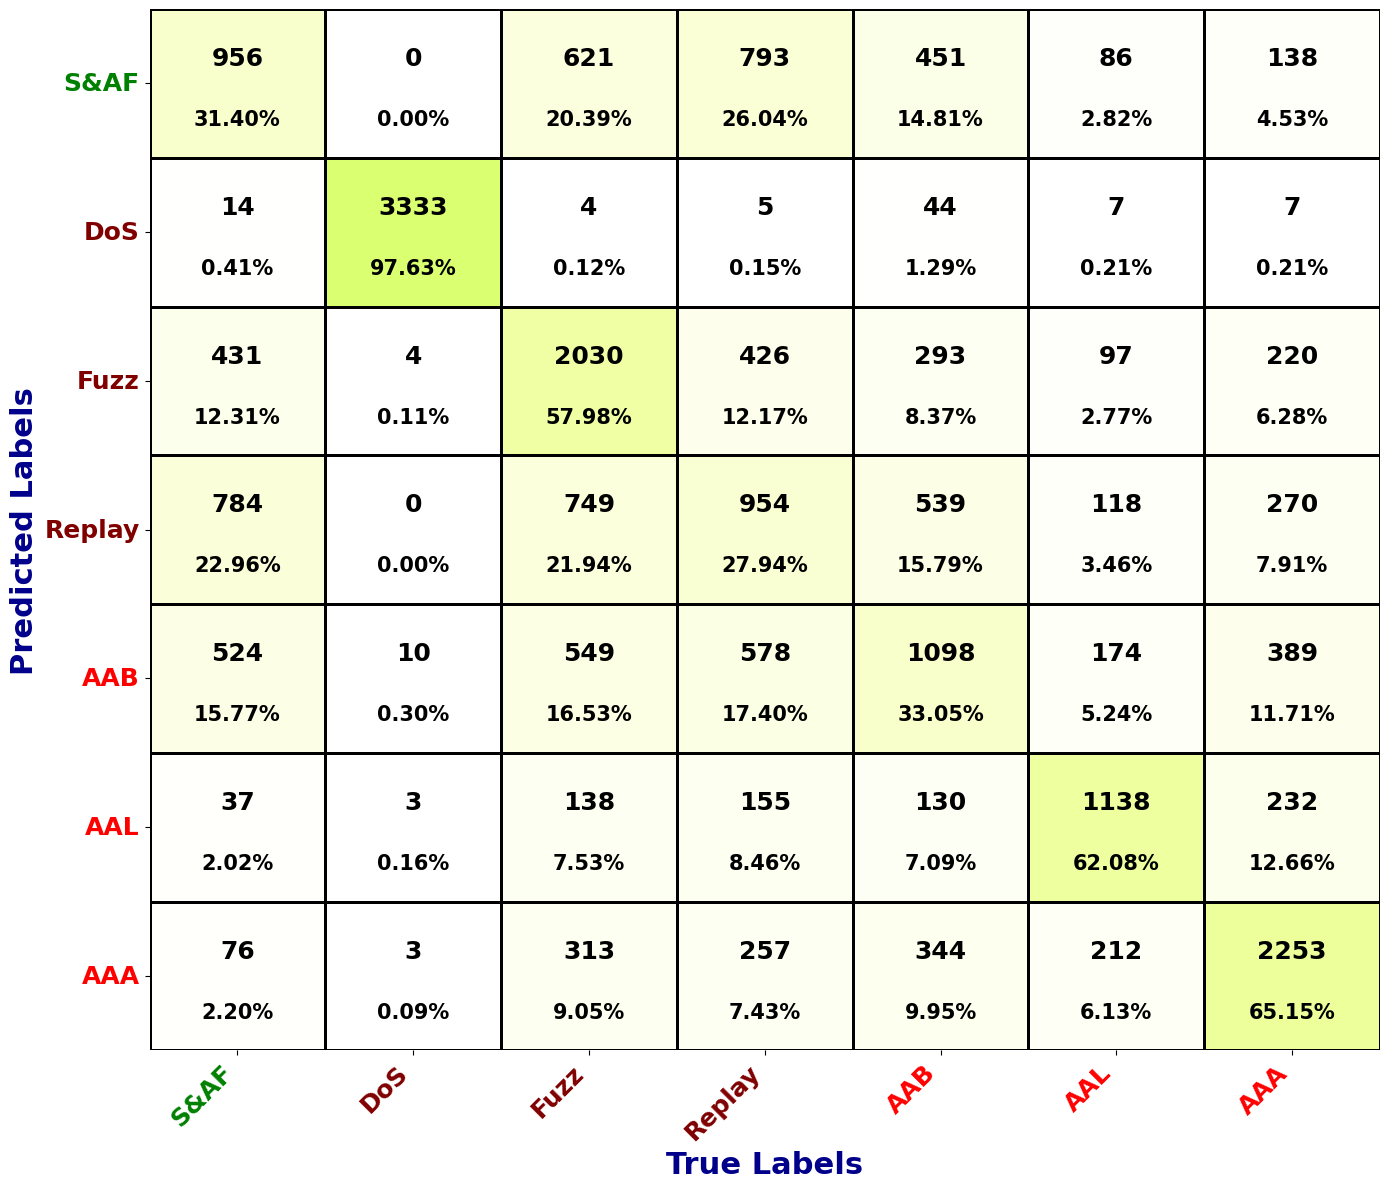

In [20]:
# --- Updated class labels --- #
class_labels = ["S&AF", "DoS", "Fuzz", "Replay", "AAB", "AAL", "AAA"]
PlotConfusionMatrixKia(cf_matrix, class_labels)

In [21]:
stats_df = ComputeFullMetrics(cf_matrix, class_labels)
stats_df

,Class,Support,Precision,Recall,F1,Accuracy,Error_Rate,CI_Lower,CI_Upper,AUC
0,S&AF,3045,0.3388,0.3140,0.3259,0.3140,0.6860,0.2977,0.3307,1.0
1,DoS,3414,0.9940,0.9763,0.9851,0.9763,0.0237,0.9706,0.9809,1.0
2,Fuzz,3501,0.4609,0.5798,0.5136,0.5798,0.4202,0.5634,0.5961,1.0
3,Replay,3414,0.3011,0.2794,0.2899,0.2794,0.7206,0.2646,0.2947,1.0
4,AAB,3322,0.3788,0.3305,0.3530,0.3305,0.6695,0.3147,0.3467,1.0
5,AAL,1833,0.6212,0.6208,0.6210,0.6208,0.3792,0.5984,0.6428,1.0
6,AAA,3458,0.6421,0.6515,0.6468,0.6515,0.3485,0.6355,0.6672,1.0


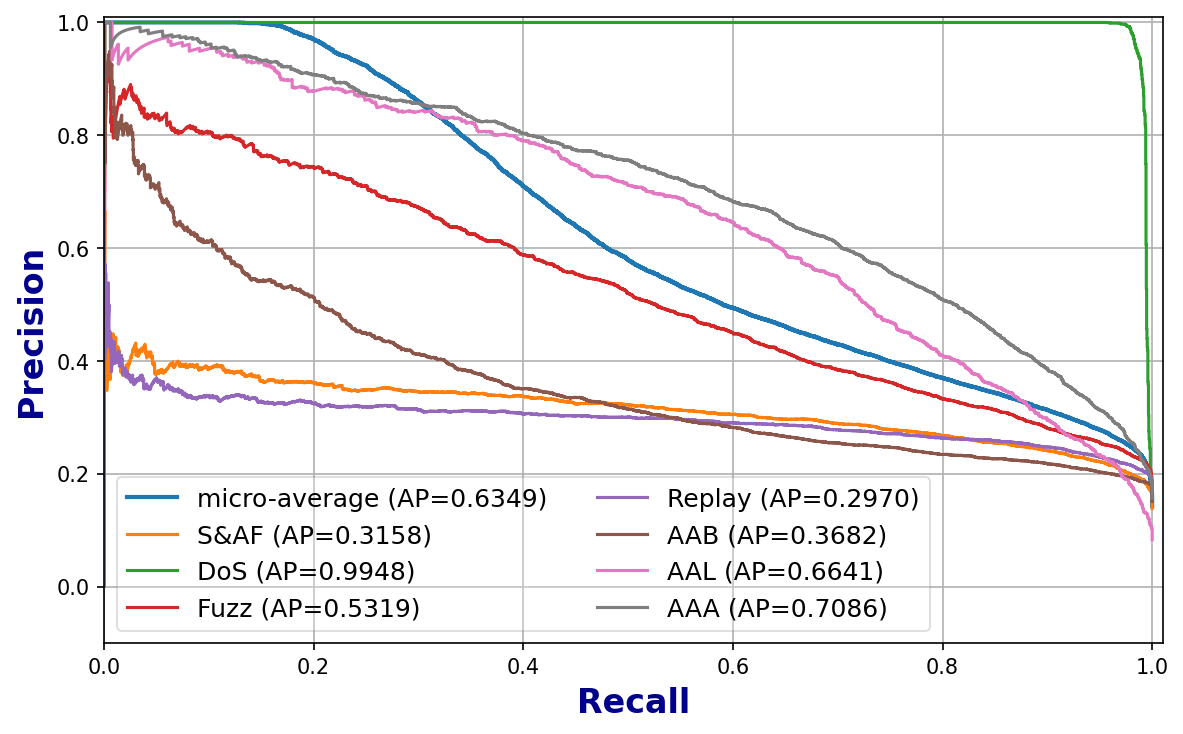

{'AP_micro': 0.6348604284793691,
 'AP_macro': 0.5543372554036522,
 'AP_per_class': {'S&AF': 0.31577636181624574,
  'DoS': 0.9948429120524738,
  'Fuzz': 0.5318607352026613,
  'Replay': 0.2969986098221126,
  'AAB': 0.3681734743136001,
  'AAL': 0.6640771760351329,
  'AAA': 0.7086315185833395}}

In [22]:
y_test, y_score = LiParGetProbsAndLabels(model, test_loader, device)
PlotPRCurve(
    y_true=y_test,
    y_score=y_score,
    class_labels=["S&AF", "DoS", "Fuzz", "Replay", "AAB", "AAL", "AAA"],
    xlim=(-0.0, 1.01),
    ylim=(-0.1, 1.01),
)